## Random Forest and XG boost on All features

#### Business Value Definition

> For this analysis, customer business value is approximated using multiple customer characteristics. High business-value customers are those with **High Spend, Annual/Quarterly Contract Length, Premium/Standard Subscription Type, Medium/High Tenure, High Usage Frequency, and Low Last Interaction**. Conversely, low business-value customers are characterized by **Low Spend, Monthly Contract Length, Basic Subscription Type, Low/Very Low Tenure, Low Usage Frequency, and High Last Interaction**.


In [2]:
import pandas as pd
import site
import sys

sys.path.append(site.getusersitepackages())

In [3]:
df = pd.read_csv("../Data/Cleaned/customer_churn_dataset.csv")
df.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
2,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
3,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
4,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0


## Feature Engineering

In [4]:
import numpy as np

# Support Calls
df["Issue_Level"] = np.where(
    df["Support Calls"] <= 2,
    "Low Issues",
    np.where(
        df["Support Calls"] <= 4,
        "Medium Issues",
        "High Issues"
    )
)

# Payment Delay
df["Delay_Level"] = np.where(
    df["Payment Delay"] <= 15,
    "Low Delay",
    np.where(
        df["Payment Delay"] <= 20,
        "Medium Delay",
        "High Delay"
    )
)

# Total Spend
df["Spend_Level"] = np.where(
    df["Total Spend"] <= 508,
    "Low Spend",
    "High Spend"
)

# Age
df["Age_Group"] = np.where(
    df["Age"] <= 19,
    "Very Young",
    np.where(
        df["Age"] <= 29,
        "Young Adult",
        np.where(
            df["Age"] <= 39,
            "Old Adult",
            "Old"
        )
    )
)

# Last Interaction
df["LI_Level"] = np.where(
    df["Last Interaction"] <= 15,
    "Low LI",
    "High LI"
)

# Usage Frequency
df["UF_Level"] = np.where(
    df["Usage Frequency"] <= 9,
    "Low UF",
    "High UF"
)

# Tenure
df["Tenure_Level"] = np.where(
    df["Tenure"] <= 5,
    "Very Low Tenure",
    np.where(
        df["Tenure"] <= 11,
        "Low Tenure",
        np.where(
            df["Tenure"] <= 24,
            "Medium Tenure",
            "High Tenure"
        )
    )
)

In [5]:
X = df[["Issue_Level","Delay_Level","Spend_Level","Contract Length","Age_Group","LI_Level","Tenure_Level","UF_Level","Gender","Subscription Type"]]
y = df["Churn"]
x = pd.get_dummies(
    X,
    drop_first=False,
    dtype= int
)

### train-test split

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,X_train_original,X_test_original,y_train,y_test = train_test_split(x,X,y,test_size=0.2,random_state=42,stratify = y)

## Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

#### Hyperparamter tuning

In [8]:
param_grid1 = {
    "n_estimators": [100, 200, 300],
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [9]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid1,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

#### Model training

In [10]:
random_search.fit(x_train, y_train)

/usr/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also

In [11]:
best_model1 = random_search.best_estimator_

### Performace Metrics

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Prediction
y_pred_RF = best_model1.predict(x_test)

# Probability Prediction
y_prob_RF = best_model1.predict_proba(x_test)[:,1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_RF))
print("Precision:", precision_score(y_test, y_pred_RF))
print("Recall   :", recall_score(y_test, y_pred_RF))
print("F1 Score :", f1_score(y_test, y_pred_RF))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_RF))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_RF))

print("\nClassification Report")
print(classification_report(y_test, y_pred_RF))

Accuracy : 0.915648938065359
Precision: 0.8858306030427872
Recall   : 0.9735467655394927
F1 Score : 0.9276196784795292
ROC AUC  : 0.9429431550886298

Confusion Matrix
[[37904  7039]
 [ 1484 54615]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.96      0.84      0.90     44943
         1.0       0.89      0.97      0.93     56099

    accuracy                           0.92    101042
   macro avg       0.92      0.91      0.91    101042
weighted avg       0.92      0.92      0.91    101042



### Feature Importance

RANDOM FOREST FEATURE IMPORTANCE (ALL FEATURES)
                     Feature  Importance
     Issue_Level_High Issues    0.210341
      Issue_Level_Low Issues    0.109367
       Spend_Level_Low Spend    0.104969
      Delay_Level_High Delay    0.103764
      Spend_Level_High Spend    0.102817
     Contract Length_Monthly    0.101849
       Delay_Level_Low Delay    0.032043
   Issue_Level_Medium Issues    0.031237
            LI_Level_High LI    0.025104
             LI_Level_Low LI    0.024515
                 Gender_Male    0.022739
               Gender_Female    0.019963
      Contract Length_Annual    0.019202
    Delay_Level_Medium Delay    0.017407
   Contract Length_Quarterly    0.017001
       Age_Group_Young Adult    0.010661
               Age_Group_Old    0.007840
  Tenure_Level_Medium Tenure    0.007646
         Age_Group_Old Adult    0.005590
    Tenure_Level_High Tenure    0.004193
            UF_Level_High UF    0.003750
             UF_Level_Low UF    0.003665
     Subs

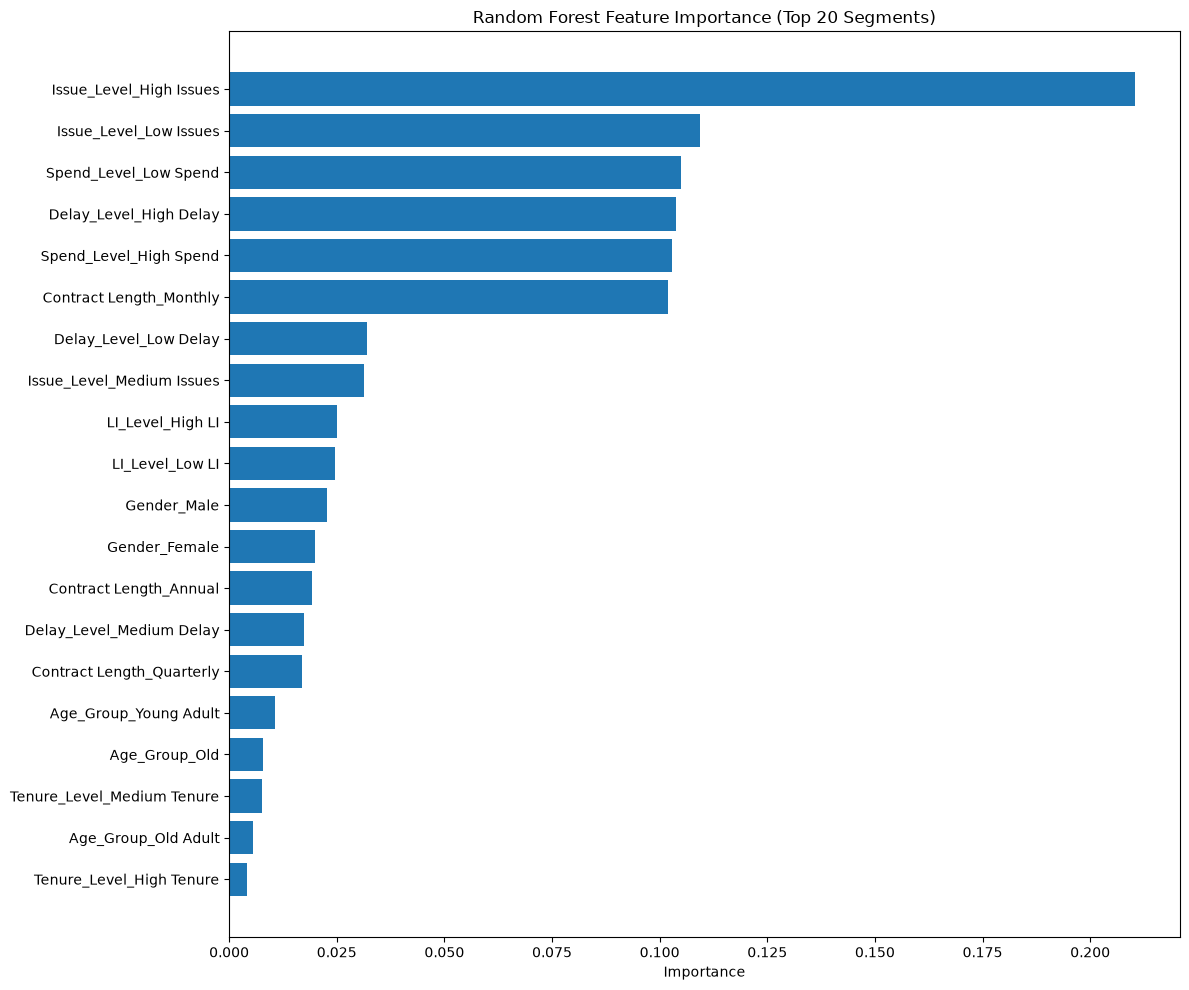

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from your Random Forest model
importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": best_model1.feature_importances_
}).sort_values("Importance", ascending=False)

# Show all features
print("="*60)
print("RANDOM FOREST FEATURE IMPORTANCE (ALL FEATURES)")
print("="*60)
print(importance_df.to_string(index=False))

# Save to CSV
importance_df.to_csv("rf_feature_importance_all_features.csv", index=False)

# Visualize top 20
plt.figure(figsize=(12, 10))
plt.barh(importance_df.head(20)["Feature"], importance_df.head(20)["Importance"])
plt.title("Random Forest Feature Importance (Top 20 Segments)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Feature importance analysis on the final Random Forest model confirmed that the engineered features are the dominant predictors of churn.

#### Top Drivers of Churn

| Segment | Importance | Interpretation |
| :--- | :--- | :--- |
| Issue_Level_High Issues | 0.210 | 5+ support calls is the #1 churn indicator |
| Issue_Level_Low Issues | 0.109 | Low issues strongly predict retention |
| Spend_Level_Low Spend | 0.105 | Low spenders are at high risk |
| Delay_Level_High Delay | 0.104 | 21+ days payment delay is a major red flag |
| Spend_Level_High Spend | 0.103 | High spenders are less likely to churn |
| Contract Length_Monthly | 0.102 | Monthly contracts drive churn |

#### Duality Patterns

The model learned clear "positive vs negative" patterns for each engineered feature:
- High Issues (0.210) vs Low Issues (0.109) → Issues drive churn
- Low Spend (0.105) vs High Spend (0.103) → Spend level matters
- High Delay (0.104) vs Low Delay (0.032) → Delay drives churn
- Monthly (0.102) vs Annual/Quarterly (~0.018) → Contract type matters

#### What Doesn't Matter

| Segment | Importance | Verdict |
| :--- | :--- | :--- |
| Age Groups | <0.011 | Weak signal |
| Tenure Levels | <0.008 | Very weak |
| Gender | ~0.022 | Weak signal |
| Subscription Type | <0.002 | Noise |

These features contribute <3% combined and can be safely ignored in future iterations.

**Conclusion** : It confirms the top features contributing to the churn as we also saw in SQL univariate analysis.

### Segment Wise Performace Evaulation

In [30]:
results_RF = X_test_original.copy()

results_RF["Actual"] = y_test.values
results_RF["Predicted"] = y_pred_RF

In [31]:
false_negative = results_RF[
    (results_RF["Actual"] == 1) &
    (results_RF["Predicted"] == 0)
]

false_negative.head()

,Issue_Level,Delay_Level,Spend_Level,Contract Length,Age_Group,LI_Level,Tenure_Level,UF_Level,Gender,Subscription Type,Actual,Predicted
141966,Low Issues,Medium Delay,High Spend,Annual,Old,High LI,High Tenure,Low UF,Male,Premium,1.0,0.0
61261,Low Issues,Low Delay,High Spend,Annual,Old,Low LI,High Tenure,High UF,Female,Standard,1.0,0.0
273619,Medium Issues,Low Delay,High Spend,Annual,Old,Low LI,Medium Tenure,High UF,Female,Premium,1.0,0.0
314474,Medium Issues,Medium Delay,High Spend,Quarterly,Old,Low LI,High Tenure,High UF,Male,Standard,1.0,0.0
206052,Low Issues,Low Delay,High Spend,Quarterly,Old,Low LI,High Tenure,Low UF,Female,Basic,1.0,0.0


In [ ]:
false_positive = results_RF[
    (results_RF["Actual"] == 0) &
    (results_RF["Predicted"] == 1)
]

false_positive.head()

,Issue_Level,Delay_Level,Spend_Level,Contract Length,Age_Group,LI_Level,Tenure_Level,UF_Level,Gender,Subscription Type,Actual,Predicted
5192,Medium Issues,Low Delay,High Spend,Monthly,Young Adult,Low LI,High Tenure,High UF,Male,Premium,0.0,1.0
50894,Medium Issues,Low Delay,Low Spend,Quarterly,Young Adult,High LI,High Tenure,High UF,Male,Standard,0.0,1.0
90680,Low Issues,High Delay,High Spend,Annual,Old,High LI,High Tenure,Low UF,Female,Basic,0.0,1.0
18573,Medium Issues,Low Delay,Low Spend,Monthly,Very Young,High LI,High Tenure,High UF,Female,Basic,0.0,1.0
82807,Medium Issues,Low Delay,Low Spend,Quarterly,Old,High LI,Very Low Tenure,High UF,Male,Standard,0.0,1.0


In [33]:
fp_rate = (
    false_positive["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Spend_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Spend_Level
High Spend     8.48
Low Spend     99.63
Name: count, dtype: float64


In [34]:
fn_rate = (
    false_negative["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Spend_Level"].value_counts()
)

print((fn_rate * 100).round(2))

Spend_Level
High Spend    5.00
Low Spend     0.06
Name: count, dtype: float64


In [35]:
fp_rate = (
    false_positive["Issue_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Issue_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Issue_Level
High Issues      100.00
Low Issues         7.36
Medium Issues     12.56
Name: count, dtype: float64


In [36]:
fp_rate = (
    false_negative["Issue_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Issue_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Issue_Level
High Issues      0.00
Low Issues       6.02
Medium Issues    7.03
Name: count, dtype: float64


In [37]:
fp_rate = (
    false_positive["Delay_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Delay_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Delay_Level
High Delay      100.00
Low Delay        14.16
Medium Delay      9.62
Name: count, dtype: float64


In [38]:
fp_rate = (
    false_negative["Delay_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Delay_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Delay_Level
High Delay      0.00
Low Delay       4.25
Medium Delay    4.21
Name: count, dtype: float64


In [39]:
fp_rate = (
    false_negative["Contract Length"].value_counts()
    /
    X_test_original[y_test == 1]["Contract Length"].value_counts()
)

print((fp_rate * 100).round(2))

Contract Length
Annual       4.23
Monthly       NaN
Quarterly    3.90
Name: count, dtype: float64


In [40]:
fp_rate = (
    false_positive["Contract Length"].value_counts()
    /
    X_test_original[y_test == 0]["Contract Length"].value_counts()
)

print((fp_rate * 100).round(2))

Contract Length
Annual        11.44
Quarterly     11.39
Monthly      100.00
Name: count, dtype: float64


In [42]:
fp_rate = (
    false_negative["Tenure_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Tenure_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Tenure_Level
High Tenure        2.74
Medium Tenure      2.19
Low Tenure         2.95
Very Low Tenure    2.75
Name: count, dtype: float64


In [44]:
fp_rate = (
    false_positive["Tenure_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Tenure_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Tenure_Level
High Tenure        13.50
Medium Tenure      21.53
Low Tenure         15.90
Very Low Tenure    21.10
Name: count, dtype: float64


In [45]:
fp_rate = (
    false_negative["UF_Level"].value_counts()
    /
    X_test_original[y_test == 1]["UF_Level"].value_counts()
)

print((fp_rate * 100).round(2))

UF_Level
High UF    2.87
Low UF     2.14
Name: count, dtype: float64


In [46]:
fp_rate = (
    false_positive["UF_Level"].value_counts()
    /
    X_test_original[y_test == 0]["UF_Level"].value_counts()
)

print((fp_rate * 100).round(2))

UF_Level
High UF    15.31
Low UF     16.71
Name: count, dtype: float64


In [47]:
fp_rate = (
    false_negative["LI_Level"].value_counts()
    /
    X_test_original[y_test == 1]["LI_Level"].value_counts()
)

print((fp_rate * 100).round(2))

LI_Level
High LI    1.70
Low LI     3.63
Name: count, dtype: float64


In [79]:
fp_rate = (
    false_positive["LI_Level"].value_counts()
    /
    X_test_original[y_test == 0]["LI_Level"].value_counts()
)

print((fp_rate * 100).round(2))

LI_Level
Low LI     12.53
High LI    21.32
Name: count, dtype: float64


In [49]:
fp_rate = (
    false_positive["Age_Group"].value_counts()
    /
    X_test_original[y_test == 0]["Age_Group"].value_counts()
)

print((fp_rate * 100).round(2))

Age_Group
Old            18.41
Old Adult      11.55
Very Young     20.32
Young Adult    15.03
Name: count, dtype: float64


In [50]:
fp_rate = (
    false_negative["Age_Group"].value_counts()
    /
    X_test_original[y_test == 1]["Age_Group"].value_counts()
)

print((fp_rate * 100).round(2))

Age_Group
Old            4.03
Old Adult      1.56
Very Young     1.72
Young Adult    0.16
Name: count, dtype: float64


In [51]:
fp_rate = (
    false_negative["Subscription Type"].value_counts()
    /
    X_test_original[y_test == 1]["Subscription Type"].value_counts()
)

print((fp_rate * 100).round(2))

Subscription Type
Basic       2.63
Premium     2.81
Standard    2.49
Name: count, dtype: float64


In [52]:
fp_rate = (
    false_positive["Subscription Type"].value_counts()
    /
    X_test_original[y_test == 0]["Subscription Type"].value_counts()
)

print((fp_rate * 100).round(2))

Subscription Type
Basic       16.43
Premium     15.17
Standard    15.44
Name: count, dtype: float64


In [53]:
fp_rate = (
    false_negative["Gender"].value_counts()
    /
    X_test_original[y_test == 1]["Gender"].value_counts()
)

print((fp_rate * 100).round(2))

Gender
Female    1.82
Male      3.53
Name: count, dtype: float64


In [54]:
fp_rate = (
    false_positive["Gender"].value_counts()
    /
    X_test_original[y_test == 0]["Gender"].value_counts()
)

print((fp_rate * 100).round(2))

Gender
Male      13.09
Female    20.39
Name: count, dtype: float64


#### Observations for False Negatives



| Feature | Customer Segment | False Negatives (%) |
|----------|------------------|--------------------:|
| **Contract Length** | Annual | 4.23% |
| | Monthly | 0.00% |
| | Quarterly | 3.90% |
| **Payment Delay** | High Delay | 0.00% |
| | Low Delay | 4.25% |
| | Medium Delay | 4.20% |
| **Issue Level** | High Issues | 0.00% |
| | Low Issues | 6.02% |
| | Medium Issues | 7.03% |
| **Spend Level** | High Spend | 5.00% |
| | Low Spend | 0.06% |
| **Tenure** | High Tenure | 2.74% |
| | Medium Tenure | 2.19% |
| | Low Tenure | 2.95% |
| | Very Low Tenure | 2.75% |
| **Last Interaction** | High Last Interaction | 1.70% |
| | Low Last Interaction | 3.63% |
| **Usage Frequency** | High Usage Frequency | 2.87% |
| | Low Usage Frequency | 2.74% |
| **Age Group** | Old | 4.03% |
| | Old Adult | 1.56% |
| | Very Young | 1.72% |
| | Young Adult | 0.16% |
| **Gender** | Female | 1.82% |
| | Male | 3.53% |
| **Subscription Type** | Basic | 2.63% |
| | Premium | 2.81% |
| | Standard | 2.49% |


#### Conclusion

- The model's false negatives are primarily concentrated among **high business-value customer segments**, including customers with **Annual/Quarterly contracts, High Spend, Premium/Standard subscriptions, Medium/High Tenure, High Usage Frequency, and Low Last Interaction**. It also misses customers with **Low to Medium Payment Delay** and **Low to Medium Issue Levels**, indicating that many future churners do not exhibit obvious warning signs.
- These customers often appear healthy in terms of payment behavior and service usage despite eventually churning, making them inherently more difficult for the model to identify.
- Missing these customers can have a significant business impact because they generally contribute higher revenue, stronger long-term relationships, and greater customer lifetime value. Their churn therefore represents a larger financial loss than losing lower-value customers.
- These findings suggest that retention strategies should not rely solely on customers showing severe payment delays or frequent support issues. Businesses should also proactively monitor seemingly healthy, high-value customers whose churn risk may be driven by more subtle behavioral patterns that are not immediately apparent.

#### Observations for False Positive

1. The models misses 11.44%, 100% and 9.62% Annual, Monthly and Quarterly Non-churning Customers. 
2. The model misses 100%, 14.16% and 9.62% High, Low and Medium delay Non-Churning Customers.
3. The model misses 100%, 7.38% and 12.56% High, Low and Medium Issues Non-Churnning Customers.
4. The model misses 8.48% and 99.63% High and Low Spending Non-Churning Customers.
5. The model misses 13.5%, 21.53%, 15.9% and 21.1% High, Medium, Low and very Low Tenure Non-Churning Customers.
6. The model misses 21.32% and 12.53% High and Low Last Interaction Non-Churning Customers.
7. The model misses 15.31% and 16.71% High and Low User Frequency Non-Churning Customers.
8. The model misses 0%, 11.55%, 20.32% and 15.03% Old, Old Adult, Very Young and Young Adult Age Group Non-Churning Customers.
9. The model misses 13.09% and 20.39% Female and Male Gender Non-Churning Customers.
10. The models misses 16.43%, 15.17% and 15.44%  Basic, Premium and Standard Non-Churning Customers. 

#### False Positive Analysis

| Feature | Customer Segment | False Positives (%) |
|----------|------------------|--------------------:|
| **Contract Length** | Annual | 11.44% |
| | Monthly | 100.00% |
| | Quarterly | 9.62% |
| **Payment Delay** | High Delay | 100.00% |
| | Low Delay | 14.16% |
| | Medium Delay | 9.62% |
| **Issue Level** | High Issues | 100.00% |
| | Low Issues | 7.38% |
| | Medium Issues | 12.56% |
| **Spend Level** | High Spend | 8.48% |
| | Low Spend | 99.63% |
| **Tenure** | High Tenure | 13.50% |
| | Medium Tenure | 21.53% |
| | Low Tenure | 15.90% |
| | Very Low Tenure | 21.10% |
| **Last Interaction** | High Last Interaction | 21.32% |
| | Low Last Interaction | 12.53% |
| **Usage Frequency** | High Usage Frequency | 15.31% |
| | Low Usage Frequency | 16.71% |
| **Age Group** | Old | 0.00% |
| | Old Adult | 11.55% |
| | Very Young | 20.32% |
| | Young Adult | 15.03% |
| **Gender** | Female | 13.09% |
| | Male | 20.39% |
| **Subscription Type** | Basic | 16.43% |
| | Premium | 15.17% |
| | Standard | 15.44% |

> **Business Value Definition:**  
> For this analysis, customer business value is approximated using multiple customer characteristics. High business-value customers are those with **High Spend, Annual/Quarterly Contract Length, Premium/Standard Subscription Type, Medium/High Tenure, High Usage Frequency, and Low Last Interaction**. Conversely, low business-value customers are characterized by **Low Spend, Monthly Contract Length, Basic Subscription Type, Low/Very Low Tenure, Low Usage Frequency, and High Last Interaction**.


#### Conclusion

- The model's false positives are distributed across both high-value and low-value customer segments. From a business perspective, false positives involving high-value customers are generally more acceptable because retention efforts on these customers may strengthen long-term customer relationships and help protect future revenue, even if they were not actually at risk of churning.
- In contrast, false positives involving low-value customer segments are less desirable because they increase the cost of unnecessary retention campaigns while offering a lower expected business return.
- Therefore, an effective churn prediction model should minimize false positives among low-value customer segments while maintaining strong identification of high-value customers who are genuinely at risk of churning. This allows retention resources to be allocated more efficiently and improves the return on investment of retention campaigns.

## XG Boost

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [15]:
model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

### Hyperparamter tuning

In [16]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [17]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-2
)

### Model training

In [18]:
random_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also

In [19]:
best_model2 = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV Accuracy: 0.9160093427767301


### Performace metrics

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Prediction
y_pred_Xg = best_model2.predict(x_test)

# Probability Prediction
y_prob_Xg = best_model2.predict_proba(x_test)[:,1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_Xg))
print("Precision:", precision_score(y_test, y_pred_Xg))
print("Recall   :", recall_score(y_test, y_pred_Xg))
print("F1 Score :", f1_score(y_test, y_pred_Xg))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_Xg))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_Xg))

print("\nClassification Report")
print(classification_report(y_test, y_pred_Xg))

Accuracy : 0.9159062568041013
Precision: 0.8857536466774716
Recall   : 0.9741884882083459
F1 Score : 0.9278686576286725
ROC AUC  : 0.9441958556474329

Confusion Matrix
[[37894  7049]
 [ 1448 54651]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.96      0.84      0.90     44943
         1.0       0.89      0.97      0.93     56099

    accuracy                           0.92    101042
   macro avg       0.92      0.91      0.91    101042
weighted avg       0.92      0.92      0.92    101042



### Feature Importance

XGBOOST FEATURE IMPORTANCE (ALL FEATURES)
                     Feature  Importance
     Issue_Level_High Issues    0.277454
      Delay_Level_High Delay    0.141215
      Issue_Level_Low Issues    0.117891
      Spend_Level_High Spend    0.105545
     Contract Length_Monthly    0.104525
       Spend_Level_Low Spend    0.043291
   Issue_Level_Medium Issues    0.042441
                 Gender_Male    0.022382
            LI_Level_High LI    0.022178
             LI_Level_Low LI    0.015803
       Age_Group_Young Adult    0.014947
       Delay_Level_Low Delay    0.014389
    Delay_Level_Medium Delay    0.013518
    Tenure_Level_High Tenure    0.012748
               Gender_Female    0.008709
  Tenure_Level_Medium Tenure    0.008397
         Age_Group_Old Adult    0.007136
               Age_Group_Old    0.006487
             UF_Level_Low UF    0.006465
            UF_Level_High UF    0.003197
        Age_Group_Very Young    0.002906
Tenure_Level_Very Low Tenure    0.002796
     Subscripti

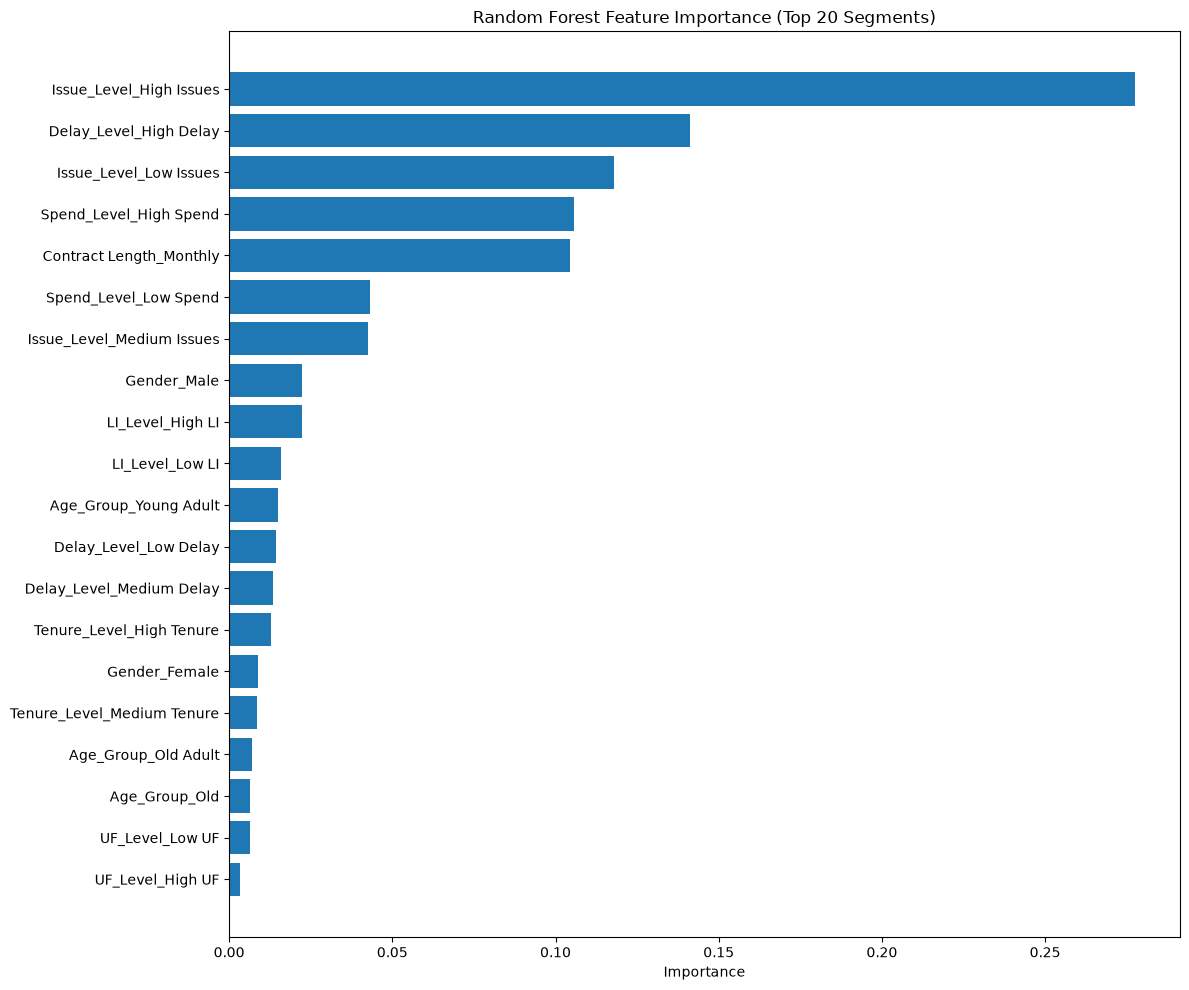

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from your Random Forest model
importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": best_model2.feature_importances_
}).sort_values("Importance", ascending=False)

# Show all features
print("="*60)
print("XGBOOST FEATURE IMPORTANCE (ALL FEATURES)")
print("="*60)
print(importance_df.to_string(index=False))

# Save to CSV
importance_df.to_csv("rf_feature_importance_all_features.csv", index=False)

# Visualize top 20
plt.figure(figsize=(12, 10))
plt.barh(importance_df.head(20)["Feature"], importance_df.head(20)["Importance"])
plt.title("Random Forest Feature Importance (Top 20 Segments)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Feature importance analysis on the final XGBoost model confirmed the 4 engineered features as the dominant predictors of churn.

#### Top Drivers of Churn

| Segment | Importance | Interpretation |
| :--- | :--- | :--- |
| Issue_Level_High Issues | 0.277 | 5+ support calls is the #1 churn indicator |
| Delay_Level_High Delay | 0.141 | 21+ days payment delay is a major red flag |
| Issue_Level_Low Issues | 0.118 | Low issues strongly predict retention |
| Spend_Level_High Spend | 0.106 | High spenders are less likely to churn |
| Contract Length_Monthly | 0.105 | Monthly contracts drive churn |

#### Duality Patterns

The model learned clear "positive vs negative" patterns:

| Feature | High Risk | Low Risk |
| :--- | :--- | :--- |
| Issue Level | High Issues (0.277) | Low Issues (0.118) |
| Delay Level | High Delay (0.141) | Low Delay (0.014) |
| Spend Level | Low Spend (0.043) | High Spend (0.106) |
| Contract Length | Monthly (0.105) | Annual/Quarterly (~0.001) |

#### What Doesn't Matter

| Feature | Importance | Verdict |
| :--- | :--- | :--- |
| Age Groups | <0.015 | Weak signal |
| Tenure Levels | <0.013 | Very weak |
| Gender | ~0.022 | Weak signal |
| Subscription Type | <0.001 | Noise |
| Contract Length_Annual | <0.001 | Noise |

These features contribute <5% combined and can be safely ignored in future iterations.

### Segmentwise performace Evaluation

In [57]:
results_Xg = X_test_original.copy()

results_Xg["Actual"] = y_test.values
results_Xg["Predicted"] = y_pred_Xg

In [58]:
false_positive = results_Xg[
    (results_Xg["Actual"] == 0) &
    (results_Xg["Predicted"] == 1)
]

false_positive.head()

,Issue_Level,Delay_Level,Spend_Level,Contract Length,Age_Group,LI_Level,Tenure_Level,UF_Level,Gender,Subscription Type,Actual,Predicted
5192,Medium Issues,Low Delay,High Spend,Monthly,Young Adult,Low LI,High Tenure,High UF,Male,Premium,0.0,1
50894,Medium Issues,Low Delay,Low Spend,Quarterly,Young Adult,High LI,High Tenure,High UF,Male,Standard,0.0,1
90680,Low Issues,High Delay,High Spend,Annual,Old,High LI,High Tenure,Low UF,Female,Basic,0.0,1
18573,Medium Issues,Low Delay,Low Spend,Monthly,Very Young,High LI,High Tenure,High UF,Female,Basic,0.0,1
82807,Medium Issues,Low Delay,Low Spend,Quarterly,Old,High LI,Very Low Tenure,High UF,Male,Standard,0.0,1


In [59]:
false_negative = results_Xg[
    (results_Xg["Actual"] == 1) &
    (results_Xg["Predicted"] == 0)
]

false_negative.head()

,Issue_Level,Delay_Level,Spend_Level,Contract Length,Age_Group,LI_Level,Tenure_Level,UF_Level,Gender,Subscription Type,Actual,Predicted
141966,Low Issues,Medium Delay,High Spend,Annual,Old,High LI,High Tenure,Low UF,Male,Premium,1.0,0
61261,Low Issues,Low Delay,High Spend,Annual,Old,Low LI,High Tenure,High UF,Female,Standard,1.0,0
273619,Medium Issues,Low Delay,High Spend,Annual,Old,Low LI,Medium Tenure,High UF,Female,Premium,1.0,0
314474,Medium Issues,Medium Delay,High Spend,Quarterly,Old,Low LI,High Tenure,High UF,Male,Standard,1.0,0
206052,Low Issues,Low Delay,High Spend,Quarterly,Old,Low LI,High Tenure,Low UF,Female,Basic,1.0,0


In [60]:
fp_rate = (
    false_positive["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Spend_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Spend_Level
High Spend     8.49
Low Spend     99.80
Name: count, dtype: float64


In [61]:
fp_rate = (
    false_negative["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Spend_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Spend_Level
High Spend    4.88
Low Spend     0.06
Name: count, dtype: float64


In [62]:
fp_rate = (
    false_positive["Issue_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Issue_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Issue_Level
High Issues      100.00
Low Issues         7.38
Medium Issues     12.59
Name: count, dtype: float64


In [81]:
fp_rate = (
    false_negative["Issue_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Issue_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Issue_Level
High Issues       NaN
Low Issues       5.88
Medium Issues    6.86
Name: count, dtype: float64


In [63]:
fp_rate = (
    false_negative["Delay_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Delay_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Delay_Level
High Delay      0.01
Low Delay       4.21
Medium Delay    3.92
Name: count, dtype: float64


In [64]:
fp_rate = (
    false_positive["Delay_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Delay_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Delay_Level
High Delay      100.00
Low Delay        14.17
Medium Delay      9.70
Name: count, dtype: float64


In [65]:
fp_rate = (
    false_negative["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Spend_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Spend_Level
High Spend    4.88
Low Spend     0.06
Name: count, dtype: float64


In [66]:
fp_rate = (
    false_positive["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Spend_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Spend_Level
High Spend     8.49
Low Spend     99.80
Name: count, dtype: float64


In [67]:
fp_rate = (
    false_negative["Contract Length"].value_counts()
    /
    X_test_original[y_test == 1]["Contract Length"].value_counts()
)

print((fp_rate * 100).round(2))

Contract Length
Annual       4.08
Monthly      0.01
Quarterly    3.85
Name: count, dtype: float64


In [68]:
fp_rate = (
    false_positive["Contract Length"].value_counts()
    /
    X_test_original[y_test == 0]["Contract Length"].value_counts()
)

print((fp_rate * 100).round(2))

Contract Length
Annual        11.49
Quarterly     11.39
Monthly      100.00
Name: count, dtype: float64


In [69]:
fp_rate = (
    false_negative["LI_Level"].value_counts()
    /
    X_test_original[y_test == 1]["LI_Level"].value_counts()
)

print((fp_rate * 100).round(2))

LI_Level
High LI    1.67
Low LI     3.53
Name: count, dtype: float64


In [70]:
fp_rate = (
    false_positive["LI_Level"].value_counts()
    /
    X_test_original[y_test == 0]["LI_Level"].value_counts()
)

print((fp_rate * 100).round(2))

LI_Level
Low LI     12.53
High LI    21.32
Name: count, dtype: float64


In [71]:
fp_rate = (
    false_negative["Tenure_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Tenure_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Tenure_Level
High Tenure        2.73
Medium Tenure      2.17
Low Tenure         2.97
Very Low Tenure    2.06
Name: count, dtype: float64


In [72]:
fp_rate = (
    false_positive["Tenure_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Tenure_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Tenure_Level
High Tenure        13.53
Medium Tenure      21.54
Low Tenure         15.86
Very Low Tenure    21.17
Name: count, dtype: float64


In [73]:
fp_rate = (
    false_negative["UF_Level"].value_counts()
    /
    X_test_original[y_test == 1]["UF_Level"].value_counts()
)

print((fp_rate * 100).round(2))

UF_Level
High UF    2.82
Low UF     2.04
Name: count, dtype: float64


In [74]:
fp_rate = (
    false_positive["UF_Level"].value_counts()
    /
    X_test_original[y_test == 0]["UF_Level"].value_counts()
)

print((fp_rate * 100).round(2))

UF_Level
High UF    15.33
Low UF     16.73
Name: count, dtype: float64


In [75]:
fp_rate = (
    false_negative["Age_Group"].value_counts()
    /
    X_test_original[y_test == 1]["Age_Group"].value_counts()
)

print((fp_rate * 100).round(2))

Age_Group
Old            3.98
Old Adult      1.42
Very Young     1.72
Young Adult    0.13
Name: count, dtype: float64


In [76]:
fp_rate = (
    false_positive["Age_Group"].value_counts()
    /
    X_test_original[y_test == 0]["Age_Group"].value_counts()
)

print((fp_rate * 100).round(2))

Age_Group
Old            18.44
Old Adult      11.56
Very Young     20.39
Young Adult    15.05
Name: count, dtype: float64


In [77]:
fp_rate = (
    false_negative["Gender"].value_counts()
    /
    X_test_original[y_test == 1]["Gender"].value_counts()
)

print((fp_rate * 100).round(2))

Gender
Female    1.75
Male      3.48
Name: count, dtype: float64


In [78]:
fp_rate = (
    false_positive["Gender"].value_counts()
    /
    X_test_original[y_test == 0]["Gender"].value_counts()
)

print((fp_rate * 100).round(2))

Gender
Male      13.08
Female    20.47
Name: count, dtype: float64


In [82]:
fp_rate = (
    false_negative["Subscription Type"].value_counts()
    /
    X_test_original[y_test == 1]["Subscription Type"].value_counts()
)

print((fp_rate * 100).round(2))

Subscription Type
Basic       2.44
Premium     2.82
Standard    2.48
Name: count, dtype: float64


In [83]:
fp_rate = (
    false_positive["Subscription Type"].value_counts()
    /
    X_test_original[y_test == 0]["Subscription Type"].value_counts()
)

print((fp_rate * 100).round(2))

Subscription Type
Basic       16.46
Premium     15.18
Standard    15.47
Name: count, dtype: float64


#### Observations of False negative
| Feature | Customer Segment | False Negatives (%) |
|---------|------------------|--------------------:|
| **Contract Length** | Annual | 4.08% |
| | Monthly | 0.01% |
| | Quarterly | 3.85% |
| **Payment Delay** | High Delay | 0.01% |
| | Low Delay | 4.21% |
| | Medium Delay | 3.92% |
| **Issue Level** | High Issues | 0.00% |
| | Low Issues | 5.88% |
| | Medium Issues | 6.86% |
| **Spend Level** | High Spend | 4.88% |
| | Low Spend | 0.06% |
| **Tenure** | High Tenure | 2.73% |
| | Medium Tenure | 2.17% |
| | Low Tenure | 2.97% |
| | Very Low Tenure | 2.06% |
| **Last Interaction** | High Last Interaction | 1.67% |
| | Low Last Interaction | 3.53% |
| **Usage Frequency** | High Usage Frequency | 2.82% |
| | Low Usage Frequency | 2.04% |
| **Age Group** | Old | 3.98% |
| | Old Adult | 1.42% |
| | Very Young | 1.72% |
| | Young Adult | 0.13% |
| **Gender** | Female | 1.75% |
| | Male | 3.48% |
| **Subscription Type** | Basic | 2.44% |
| | Premium | 2.82% |
| | Standard | 2.48% |


#### Business Value Definition

> For this analysis, customer business value is approximated using multiple customer characteristics. High business-value customers are those with **High Spend, Annual/Quarterly Contract Length, Premium/Standard Subscription Type, Medium/High Tenure, High Usage Frequency, and Low Last Interaction**. Conversely, low business-value customers are characterized by **Low Spend, Monthly Contract Length, Basic Subscription Type, Low/Very Low Tenure, Low Usage Frequency, and High Last Interaction**.

#### Conclusion

- The model's false negatives are primarily concentrated among **high business-value customer segments**, including customers with **Annual/Quarterly contracts, High Spend, Premium/Standard subscriptions, Medium/High Tenure, High Usage Frequency, and Low Last Interaction**. It also misses customers with **Low to Medium Payment Delay** and **Low to Medium Issue Levels**, indicating that many future churners do not exhibit obvious warning signs.
- These customers often appear healthy in terms of payment behavior and service usage despite eventually churning, making them inherently more difficult for the model to identify.
- Missing these customers can have a significant business impact because they generally contribute higher revenue, stronger long-term relationships, and greater customer lifetime value. Their churn therefore represents a larger financial loss than losing lower-value customers.
- These findings suggest that retention strategies should not rely solely on customers showing severe payment delays or frequent support issues. Businesses should also proactively monitor seemingly healthy, high-value customers whose churn risk may be driven by more subtle behavioral patterns that are not immediately apparent.


#### Observations False Positive

| Feature | Customer Segment | False Positives (%) |
|---------|------------------|--------------------:|
| **Contract Length** | Annual | 11.49% |
| | Monthly | 100.00% |
| | Quarterly | 11.39% |
| **Payment Delay** | High Delay | 100.00% |
| | Low Delay | 14.17% |
| | Medium Delay | 9.70% |
| **Issue Level** | High Issues | 100.00% |
| | Low Issues | 7.38% |
| | Medium Issues | 12.59% |
| **Spend Level** | High Spend | 8.49% |
| | Low Spend | 99.80% |
| **Tenure** | High Tenure | 13.53% |
| | Medium Tenure | 21.54% |
| | Low Tenure | 15.86% |
| | Very Low Tenure | 21.17% |
| **Last Interaction** | High Last Interaction | 21.32% |
| | Low Last Interaction | 12.53% |
| **Usage Frequency** | High Usage Frequency | 15.33% |
| | Low Usage Frequency | 16.73% |
| **Age Group** | Old | 18.44% |
| | Old Adult | 11.56% |
| | Very Young | 20.39% |
| | Young Adult | 15.05% |
| **Gender** | Female | 20.47% |
| | Male | 13.08% |
| **Subscription Type** | Basic | 16.46% |
| | Premium | 15.18% |
| | Standard | 15.47% |

#### Conclusion

- The model's false positives are distributed across both high-value and low-value customer segments. From a business perspective, false positives involving high-value customers are generally more acceptable because retention efforts on these customers may strengthen long-term customer relationships and help protect future revenue, even if they were not actually at risk of churning.
- In contrast, false positives involving low-value customer segments are less desirable because they increase the cost of unnecessary retention campaigns while offering a lower expected business return.
- Therefore, an effective churn prediction model should minimize false positives among low-value customer segments while maintaining strong identification of high-value customers who are genuinely at risk of churning. This allows retention resources to be allocated more efficiently and improves the return on investment of retention campaigns.

In [23]:
import shap

explainer = shap.TreeExplainer(best_model2)

In [24]:
shap_values = explainer(x_test)

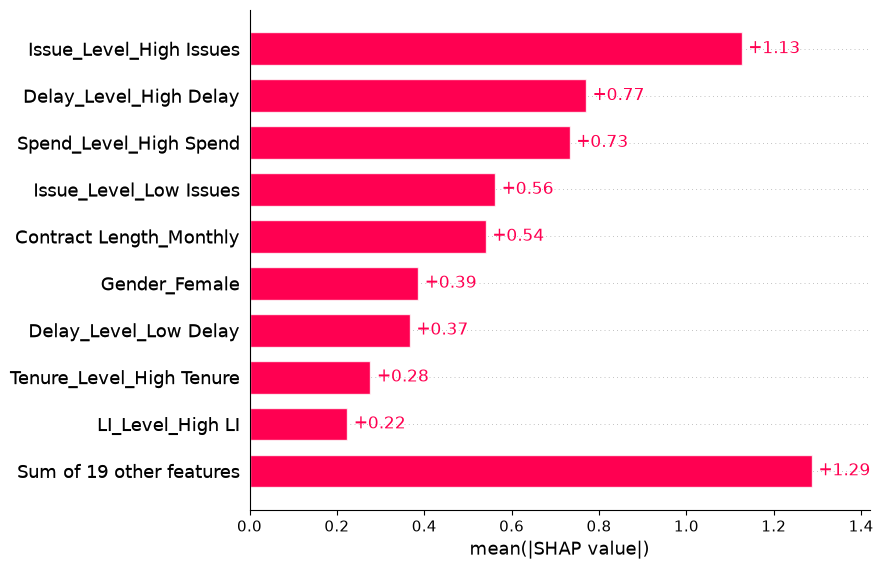

In [25]:
shap.plots.bar(shap_values, max_display=10)

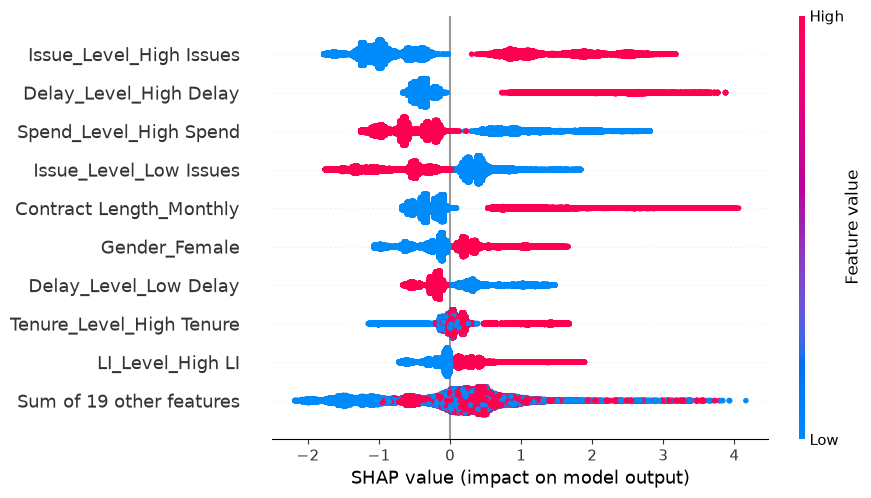

In [26]:
shap.plots.beeswarm(shap_values, max_display=10)

## SHAP Analysis

SHAP (SHapley Additive exPlanations) was used to interpret the predictions of the final XGBoost model.

### Key Findings

- High Issue Level was the most influential feature affecting churn predictions.
- Customers with High Payment Delay showed a strong positive contribution toward churn.
- Monthly Contract customers were more likely to be classified as churners.
- The model also identified meaningful contributions from customer spending level, tenure, and last interaction.
- SHAP explanations demonstrate that the final model captures complex nonlinear relationships while providing transparent and interpretable predictions.

In [27]:
customer_id = 10

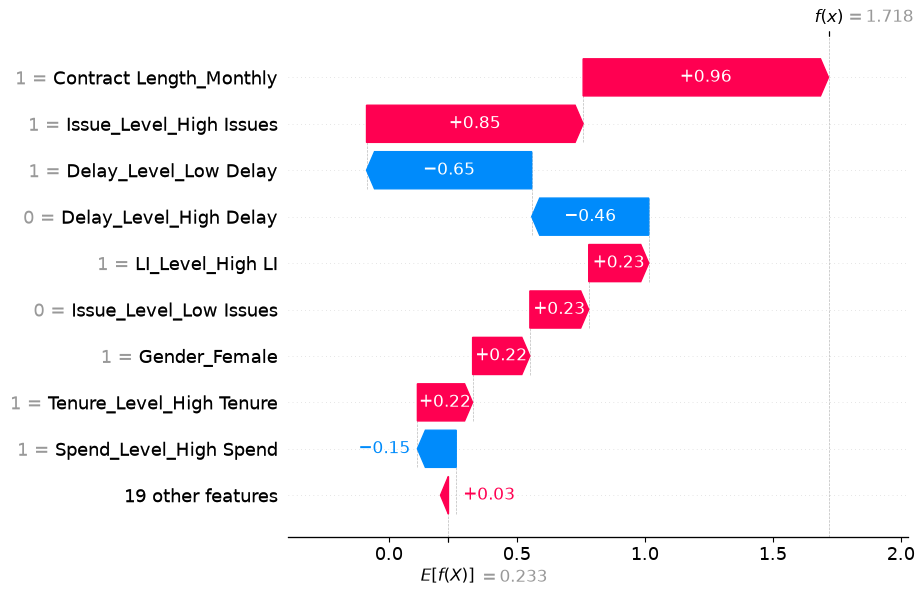

In [28]:
shap.plots.waterfall(shap_values[customer_id])

In [29]:
print("Actual:", y_test.iloc[customer_id])
print("Predicted:", y_pred_Xg[customer_id])
print("Probability:", y_prob_Xg[customer_id])

Actual: 1.0
Predicted: 1
Probability: 0.84780675


> **Note:** This SHAP waterfall plot explains the prediction for a single customer. The prediction starts from the model's average output (base value) and each feature either increases (red) or decreases (blue) the predicted probability of churn. The cumulative contribution of all features results in the final model output (`f(x)`), corresponding to the customer's predicted churn probability. In this example, the customer was correctly classified as a churner with a predicted probability of **84.78%**.

In [84]:
from joblib import dump

dump(best_model1, "random_forest_model2.joblib")

['random_forest_model2.joblib']

In [85]:
from joblib import dump

dump(best_model2, "XGboost2_model.joblib")

['XGboost2_model.joblib']